# 🏏 IPL Chase Predictor
### XGBoost Run Score Distribution Engine
---
**Model:** Hyperparameter-tuned XGBoost Regressor &nbsp;|&nbsp; **MAE:** 11.35 &nbsp;|&nbsp; **RMSE:** 17.32 &nbsp;|&nbsp; **MAPE:** 7.77% &nbsp;|&nbsp; **R²:** 0.6454

In [45]:
import joblib
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from ipl_predict_utils import apply_plot_style, build_match_state, get_prediction, \
    build_prediction_distribution, compute_metrics, plot_distribution, \
    print_match_summary, print_betting_report

apply_plot_style()

pipeline        = joblib.load('cricket_model_xgb.pkl')
residuals       = np.load('residuals.npy')
balls_left_test = np.load('balls_left_test.npy')

print('  Ready.')

  Ready.


##  Match Situation
**Edit the five values below — everything else is automatic.**

In [46]:
BATTING_TEAM  = 'Mumbai Indians'
CURRENT_SCORE = 72
BALLS_FACED   = 54
WICKETS_LOST  = 3
TARGET        = 175

# ── Auto-calculated ───────────────────────────────────────────────────────────
state = build_match_state(BATTING_TEAM, CURRENT_SCORE, BALLS_FACED, WICKETS_LOST, TARGET)
print_match_summary(state)

Match Situation Summary
────────────────────────────────────────
  Batting Team  : Mumbai Indians
  Score         : 72/3  off 54 balls  (9.0 overs)
  Target        : 175
  Runs Needed   : 103  off 66 balls  (11.0 overs)
  Current RR    : 8.00
  Required RR   : 9.36
  Wickets Left  : 7


##  Prediction & Probability Distribution

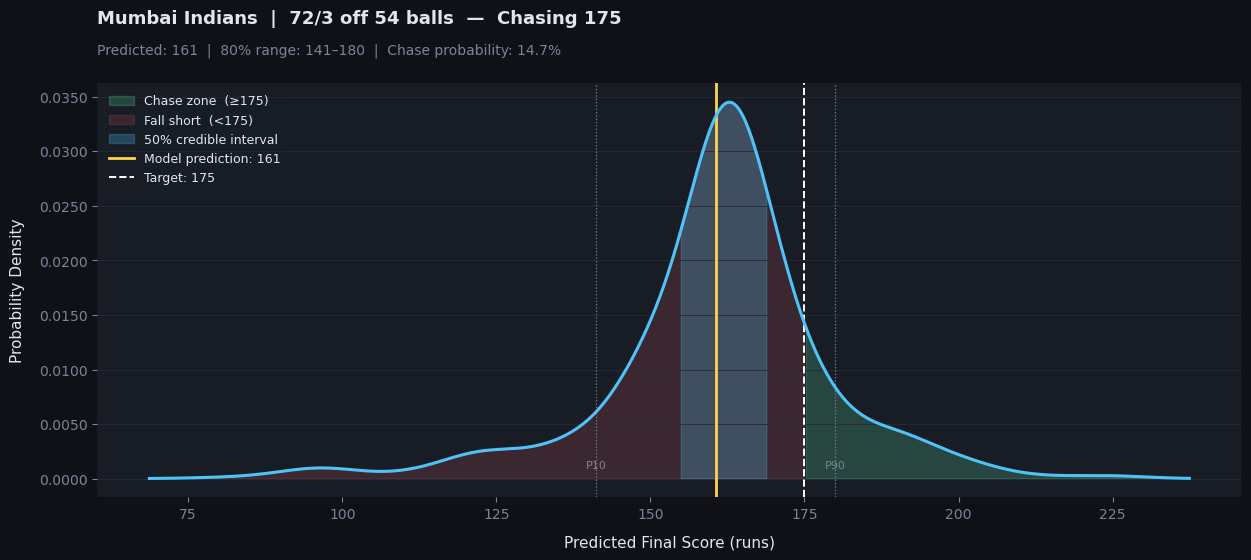

<Figure size 640x480 with 0 Axes>

In [ ]:
point_pred             = get_prediction(pipeline, state)
pred_dist, cond_resids = build_prediction_distribution(point_pred, state, residuals, balls_left_test)
metrics                = compute_metrics(pred_dist, state['target'], cond_resids)

plot_distribution(pred_dist, point_pred, state, metrics, save_path='assets/sample_distribution.png')

##  Betting Insights Report

In [44]:
print_betting_report(point_pred, state, metrics)


════════════════════════════════════════════════════
  BETTING INSIGHTS REPORT
  Mumbai Indians  chasing 175
════════════════════════════════════════════════════

  PREDICTION
  Point estimate    : 161 runs
  Median (P50)      : 162 runs
  80% range         : 141 – 180 runs
  50% range (IQR)   : 155 – 169 runs
  Model uncertainty : ± 12.0 runs  (cond. MAE at 66 balls left)

  WIN PROBABILITY
  Chase success     : 14.7%
  Fall short        : 85.3%
  Implied odds (w/l): 6.80  /  1.17
  Within ±5 of line : 12.9%  (close finish risk)

  RUNS MARKET BREAKDOWN
  Under 155             25.4%  ███████
  155–174               59.9%  █████████████████
  175–194               11.9%  ███
  Over 194               2.8%  

  MOMENTUM
  Current RR        : 8.00
  Required RR       : 9.36
  Differential      : -1.36
  Assessment        : 🟠  Negative — bowling has the edge

  RISK STATEMENT
    No major risk flags at this stage

════════════════════════════════════════════════════

